In [12]:
import os
import pickle
import hdbscan
import numpy as np
import pandas as pd
from PIL import Image
from collections import Counter
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

In [30]:
from sklearn.decomposition import PCA as PCA2D
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from collections import defaultdict

In [4]:
graphs = pickle.load(open("graphs.pkl", "rb"))

In [ ]:
def build_tensor(fp_list, all_types, G=8, image_size=256):
    C = len(all_types)
    type_to_idx = {t: i for i, t in enumerate(all_types)}
    N = len(fp_list)

    # X_all = np.zeros((N, C*3, G, G), dtype=float)  # 3 = area, count, presence
    X_all = np.zeros((N, C*2, G, G), dtype=float)  # 2 = area, count

    for i, fp in enumerate(fp_list):
        area_hist  = np.zeros((C, G, G), dtype=float)
        count_hist = np.zeros((C, G, G), dtype=float)
        pres_hist  = np.zeros((C, G, G), dtype=float)
        for room in fp["rooms"]:
            t = type_to_idx[room["type"]]
            cx, cy = room["centroid"]
            cx_n = np.clip(cx / image_size, 0, 1 - 1e-9)
            cy_n = np.clip(cy / image_size, 0, 1 - 1e-9)
            i_cell = int(cx_n * G)
            j_cell = int(cy_n * G)
            area_frac = room["area"] / (image_size*image_size)
            area_hist[t, j_cell, i_cell]  += area_frac
            count_hist[t, j_cell, i_cell] += 1
            pres_hist[t, j_cell, i_cell]    = 1
        X_all[i, 0*C:1*C, :, :] = area_hist
        X_all[i, 1*C:2*C, :, :] = count_hist
        # X_all[i, 2*C:   3*C, :, :] = pres_hist
    return X_all

In [ ]:
all_types = [
    'common_room', 
    'master_room', 
    'living_room',  
    'balcony',       
    'bathroom',      
    'kitchen',     
    'storage',      
    'dining',        
]

G = 8
num_cells = G * G 
T = len(all_types) 
feat = 2
# type_to_idx = {t: i for i, t in enumerate(all_types)}

X_all = build_tensor(graphs, all_types, G=G, image_size=256)

In [7]:
X_all.shape

(80788, 16, 8, 8)

In [8]:
class FloorplanDataset(Dataset):
    def __init__(self, X_numpy):
        self.X = torch.from_numpy(X_numpy).float()  # shape (N,24,8,8)
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        return self.X[idx]

dataset = FloorplanDataset(X_all)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True, num_workers=4)

In [ ]:
C_in = 16 
d_latent = 128

class FloorplanEncoder(nn.Module):
    def __init__(self, G=8, feat=2, C=8, d_latent=64):

        super().__init__()
        
        self.G = G
        self.C = C
        self.d_latent = d_latent
        
        # in_channels = 3 * C  # 3 features per type: area, count, presence
        in_channels = feat * C  # 2 features per type: area, count
        

        self.conv1 = nn.Conv2d(in_channels,  64, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(64)
        
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(128)
        
 
        self.pool1 = nn.MaxPool2d(2, 2)
        
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(256)

        self.pool2 = nn.MaxPool2d(2, 2)

        self.spatial_dim = G // 4  

        self.fc = nn.Linear(256 * self.spatial_dim * self.spatial_dim,
                            d_latent)
    
    def forward(self, x):


        x = F.relu(self.bn1(self.conv1(x)))    
        x = F.relu(self.bn2(self.conv2(x)))   
        x = self.pool1(x)                      
        
        x = F.relu(self.bn3(self.conv3(x)))   
        x = self.pool2(x)                      
        
        b, c, h, w = x.shape
        # print(c)
        # print(h)
        # print(w)
        # print(self.spatial_dim)
        assert c == 256 and h == self.spatial_dim and w == self.spatial_dim
        x = x.view(b, -1)                  
        
        z = self.fc(x)             
        return z


class FloorplanDecoder(nn.Module):
    def __init__(self, G=16, feat=2, C=8, d_latent=64):
        """
        G: grid size (same as encoder). Must be divisible by 4.
        C: number of room types (8).
        d_latent: dimension of the bottleneck code.
        """
        super().__init__()
        assert G % 4 == 0
        self.G = G
        self.C = C
        self.d_latent = d_latent
        
     
        self.spatial_dim = G // 4
        

        self.fc = nn.Linear(d_latent, 256 * self.spatial_dim * self.spatial_dim)

        self.deconv1 = nn.ConvTranspose2d(256, 128, kernel_size=3, padding=1)
        self.bn1     = nn.BatchNorm2d(128)
        self.upsamp1 = nn.Upsample(scale_factor=2, mode='nearest') 
        

        self.deconv2 = nn.ConvTranspose2d(128, 64, kernel_size=3, padding=1)
        self.bn2     = nn.BatchNorm2d(64)
        self.upsamp2 = nn.Upsample(scale_factor=2, mode='nearest') 
        
        # Final deconv: (64 → 3*C) at (G, G)
        self.deconv3 = nn.ConvTranspose2d(64, feat * C, kernel_size=3, padding=1)
    
    def forward(self, z):

        b = z.size(0)

        x = F.relu(self.fc(z))                     
        x = x.view(b, 256, self.spatial_dim, self.spatial_dim) 

        x = F.relu(self.bn1(self.deconv1(x)))  
        x = self.upsamp1(x)                    
        

        x = F.relu(self.bn2(self.deconv2(x))) 
        x = self.upsamp2(x)                    
        
 
        x = torch.sigmoid(self.deconv3(x))    
        return x


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [11]:
encoder = FloorplanEncoder(feat=feat, G=G, d_latent=d_latent).to(device)
decoder = FloorplanDecoder(feat=feat, G=G, d_latent=d_latent).to(device)

In [12]:
criterion = nn.MSELoss()
optimizer = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=1e-3)

In [ ]:
num_epochs = 30
for epoch in range(num_epochs):
    encoder.train()
    decoder.train()
    running_loss = 0.0
    for X_batch in dataloader: 
        X_batch = X_batch.to(device)
        optimizer.zero_grad()
        z = encoder(X_batch)
        X_hat = decoder(z)
        loss = criterion(X_hat, X_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss = {running_loss/len(dataset):.6f}")


encoder.eval()
all_codes = []
full_loader = DataLoader(dataset, batch_size=512, shuffle=False)
with torch.no_grad():
    for X_batch in full_loader:
        X_batch = X_batch.to(device)
        z = encoder(X_batch)      
        all_codes.append(z.cpu().numpy())
all_codes = np.vstack(all_codes)  

Epoch 1/30, Loss = 0.010707
Epoch 2/30, Loss = 0.004957
Epoch 3/30, Loss = 0.002547
Epoch 4/30, Loss = 0.001330
Epoch 5/30, Loss = 0.000746
Epoch 6/30, Loss = 0.000441
Epoch 7/30, Loss = 0.000319
Epoch 8/30, Loss = 0.000255
Epoch 9/30, Loss = 0.000214
Epoch 10/30, Loss = 0.000184
Epoch 11/30, Loss = 0.000170
Epoch 12/30, Loss = 0.000163
Epoch 13/30, Loss = 0.000155
Epoch 14/30, Loss = 0.000152
Epoch 15/30, Loss = 0.000149
Epoch 16/30, Loss = 0.000145
Epoch 17/30, Loss = 0.000144
Epoch 18/30, Loss = 0.000140
Epoch 19/30, Loss = 0.000140
Epoch 20/30, Loss = 0.000135
Epoch 21/30, Loss = 0.000137
Epoch 22/30, Loss = 0.000134
Epoch 23/30, Loss = 0.000134
Epoch 24/30, Loss = 0.000132
Epoch 25/30, Loss = 0.000131
Epoch 26/30, Loss = 0.000133
Epoch 27/30, Loss = 0.000129
Epoch 28/30, Loss = 0.000128
Epoch 29/30, Loss = 0.000130
Epoch 30/30, Loss = 0.000128


In [15]:
with open("cnn_results.pkl", "wb") as f:
    pickle.dump(all_codes, f)

In [4]:
all_codes = pickle.load(open("./cnn_results.pkl", "rb"))

In [5]:
scaler = StandardScaler().fit(all_codes)
Z_scaled = scaler.transform(all_codes)

In [6]:
Z_scaled.shape

(80788, 128)

In [94]:
clusterer_hdb = hdbscan.HDBSCAN(
    min_cluster_size=100,
    min_samples=20,
    metric="euclidean",
    cluster_selection_method="eom"
)
labels_hdb = clusterer_hdb.fit_predict(Z_scaled)

/home/airlay88/planscape/venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/airlay88/planscape/venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [19]:
linkage_matrix = sch.linkage(Z_pca32[:40000], method='ward')

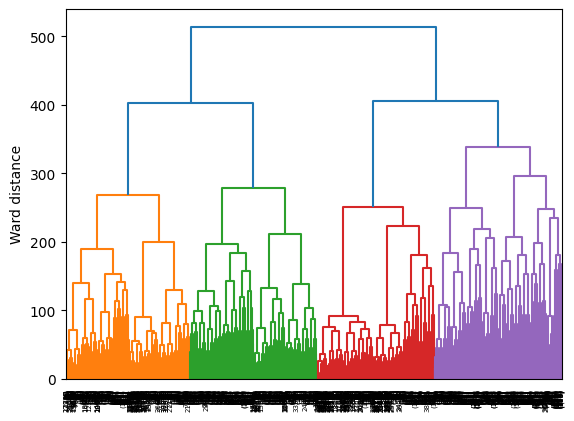

In [20]:
sch.dendrogram(linkage_matrix, truncate_mode='level', p=10)
plt.ylabel("Ward distance")
plt.show()

In [13]:
pca = PCA(n_components=64, random_state=42)
Z_pca32 = pca.fit_transform(Z_scaled)

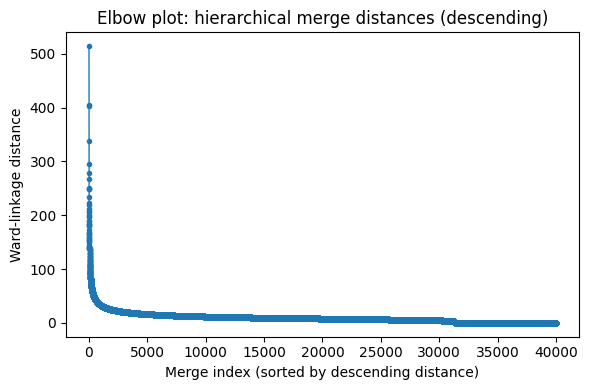

In [ ]:
Z = linkage(Z_pca32[:40000], method="ward") 


distances = Z[:, 2] 


dist_desc = np.sort(distances)[::-1]

plt.figure(figsize=(6, 4))
plt.plot(dist_desc, marker="o", markersize=3, linewidth=1)
plt.xlabel("Merge index (sorted by descending distance)")
plt.ylabel("Ward‐linkage distance")
plt.title("Elbow plot: hierarchical merge distances (descending)")
plt.tight_layout()
plt.show()



In [ ]:
dist_desc = np.sort(Z[:,2])[::-1]
diffs = dist_desc[:-1] - dist_desc[1:] 


i_star_all = np.argmax(diffs)     
i_star = np.argmax(diffs[1:]) + 1 
print("Elbow at i_star =", i_star)
K = Z_pca32[:40000].shape[0] - i_star
K

Elbow at i_star = 2


39998


Agglomerative clustering with K=8:
  Cluster  0: 4883 plans
  Cluster  1: 7441 plans
  Cluster  2: 3955 plans
  Cluster  3: 10631 plans
  Cluster  4: 2333 plans
  Cluster  5: 2013 plans
  Cluster  6: 5180 plans
  Cluster  7: 3564 plans


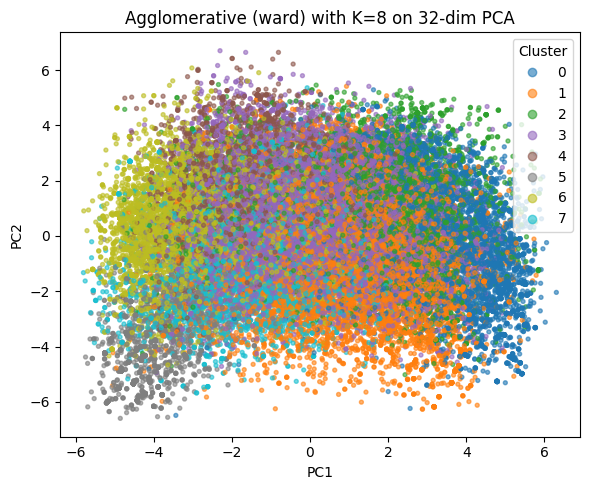

In [ ]:

K = 8


agg = AgglomerativeClustering(
    n_clusters=K,
    linkage="ward"
)
labels_hier = agg.fit_predict(Z_pca32[:40000])  

cnt = Counter(labels_hier)
print(f"\nAgglomerative clustering with K={K}:")
for cluster_id, size in sorted(cnt.items()):
    print(f"  Cluster {cluster_id:>2}: {size} plans")


from sklearn.decomposition import PCA as PCA2D

pca2 = PCA2D(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(Z_pca32[:40000])

plt.figure(figsize=(6, 5))
scatter = plt.scatter(
    X_pca2[:, 0], X_pca2[:, 1],
    c=labels_hier, cmap="tab10", s=8, alpha=0.6
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Agglomerative (ward) with K={K} on 32‐dim PCA")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.tight_layout()
plt.show()

In [ ]:
labels = labels_hier
X = Z_pca32[:40000]
unique_labels = np.unique(labels)

unique_labels = unique_labels[unique_labels >= 0]

C = len(unique_labels)
rep_idx = {}

cluster_to_members = defaultdict(list)
for i, c in enumerate(labels):
    if c < 0:
        continue   
    cluster_to_members[c].append(i)


for c in unique_labels:
    members = np.array(cluster_to_members[c])  
    features = X[members]                     
    centroid = np.mean(features, axis=0)     


    diffs = features - centroid            
    d2   = np.sum(diffs**2, axis=1)           


    argmin_within = np.argmin(d2)
    rep_idx[c] = members[argmin_within]     

print("Representative index per cluster:", rep_idx)

Representative index per cluster: {0: 26213, 1: 36122, 2: 16093, 3: 27039, 4: 35011, 5: 7998, 6: 16348, 7: 26127}


In [28]:
labels

array([3, 0, 2, ..., 7, 1, 0])

In [10]:
K = 12
agg = AgglomerativeClustering(n_clusters=K, linkage="ward")
labels_agg = agg.fit_predict(Z_pca32[:40000])

In [11]:
print("agglomeration cluster sizes:", Counter(labels_agg))

agglomeration cluster sizes: Counter({6: 5180, 1: 5110, 10: 5106, 7: 4963, 2: 3955, 0: 3723, 3: 3564, 4: 2333, 9: 2331, 5: 2013, 8: 1160, 11: 562})


In [95]:
print("HDBSCAN cluster sizes:", Counter(labels_hdb))

HDBSCAN cluster sizes: Counter({-1: 71047, 22: 1505, 31: 674, 16: 614, 15: 558, 12: 427, 6: 403, 1: 326, 35: 306, 27: 305, 14: 283, 2: 281, 33: 269, 29: 250, 7: 245, 28: 209, 30: 201, 4: 199, 9: 199, 32: 198, 26: 192, 10: 183, 21: 179, 3: 172, 23: 151, 11: 148, 8: 128, 13: 124, 19: 123, 25: 121, 5: 117, 18: 116, 20: 115, 17: 110, 24: 105, 0: 105, 34: 100})
